# ***Fashion Trend Analysis***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("../Datasets/Fashion_Trends.csv")

In [3]:
color = sb.color_palette("crest",5)

In [4]:
df

,Brand,Description,Product_ID,Discount_Price,Original_Price,Gender,Category,Discounted_amount,Discount_Percentage,Product_Name,Price_Segment,Discount_Tier
0,performax,Typographic Print Track Pants with Insert Pockets,441136763008,974,1299,Men,Activewear,325,25.02,Track Pants,Mid (₹500–₹1499),Moderate (20-40%)
1,performax,Low-Top Lace-Up Sports Shoes,450137679013,1499,1499,Men,Activewear,0,0.00,Sports Shoes,Mid (₹500–₹1499),No Discount
2,teamspirit,Colorblock Crew-Neck T-shirt,441133214008,461,549,Men,Activewear,88,16.03,Crew-Neck T-shirt,Mid (₹500–₹1499),Light (10-20%)
3,performax,Camouflage Print Joggers with Insert Pockets,441134776020,1189,1699,Men,Activewear,510,30.02,Print Joggers,Premium (₹1500–₹3999),Moderate (20-40%)
4,teamspirit,Reflective Colourblock Crew-Neck T-shirt,441136539020,425,599,Men,Activewear,174,29.05,Crew-Neck T-shirt,Mid (₹500–₹1499),Moderate (20-40%)
...,...,...,...,...,...,...,...,...,...,...,...,...
31577,ajio,Printed Top with Raglan Sleeves,460328028004,1299,1299,Women,Westernwear,0,0.00,Printed Top,Mid (₹500–₹1499),No Discount
31578,ajio,Striped Cropped Pants with Belt,460328036004,2099,2099,Women,Westernwear,0,0.00,Cropped Pants,Premium (₹1500–₹3999),No Discount
31579,ajio,Striped City Shorts with Belt,460328005002,1499,1499,Women,Westernwear,0,0.00,City Shorts,Mid (₹500–₹1499),No Discount
31580,ajio,Denim Jacket with Frayed Hemline,460328651009,2999,2999,Women,Westernwear,0,0.00,Denim Jacket,Premium (₹1500–₹3999),No Discount


In [5]:
df.isnull().sum()

Brand                  0
Description            0
Product_ID             0
Discount_Price         0
Original_Price         0
Gender                 0
Category               0
Discounted_amount      0
Discount_Percentage    0
Product_Name           0
Price_Segment          0
Discount_Tier          0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31582 entries, 0 to 31581
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Brand                31582 non-null  object 
 1   Description          31582 non-null  object 
 2   Product_ID           31582 non-null  int64  
 3   Discount_Price       31582 non-null  int64  
 4   Original_Price       31582 non-null  int64  
 5   Gender               31582 non-null  object 
 6   Category             31582 non-null  object 
 7   Discounted_amount    31582 non-null  int64  
 8   Discount_Percentage  31582 non-null  float64
 9   Product_Name         31582 non-null  object 
 10  Price_Segment        31582 non-null  object 
 11  Discount_Tier        31582 non-null  object 
dtypes: float64(1), int64(4), object(7)
memory usage: 2.9+ MB


# Exploratory Data Analysis (EDA):

### Distribution of numerical features

In [7]:
df[['Discount_Price', 'Original_Price', 'Discounted_amount', 'Discount_Percentage']].describe()

,Discount_Price,Original_Price,Discounted_amount,Discount_Percentage
count,31582.000000,31582.000000,31582.000000,31582.000000
mean,929.759832,1418.094769,488.334938,32.979031
std,727.207471,945.684511,544.062245,24.667178
min,75.000000,149.000000,0.000000,0.000000
25%,479.000000,799.000000,0.000000,0.000000
50%,735.000000,1299.000000,356.000000,35.040000
75%,1199.000000,1799.000000,749.000000,50.930000
max,16999.000000,19999.000000,11999.000000,85.010000


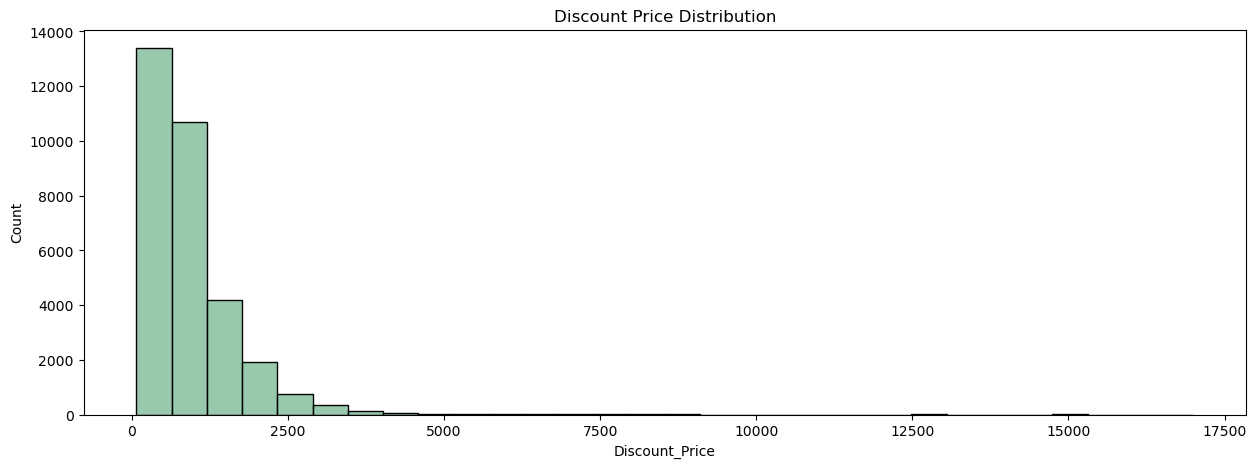

In [8]:
fig=plt.figure(figsize=(15,5))
sb.histplot(df.Discount_Price,bins=30,color=color[0])
plt.title("Discount Price Distribution")
plt.show()

### The distribution is heavily right-skewed, indicating that the inventory is dominated by budget-friendly items (mostly under 2,500) with very few high-end luxury products.

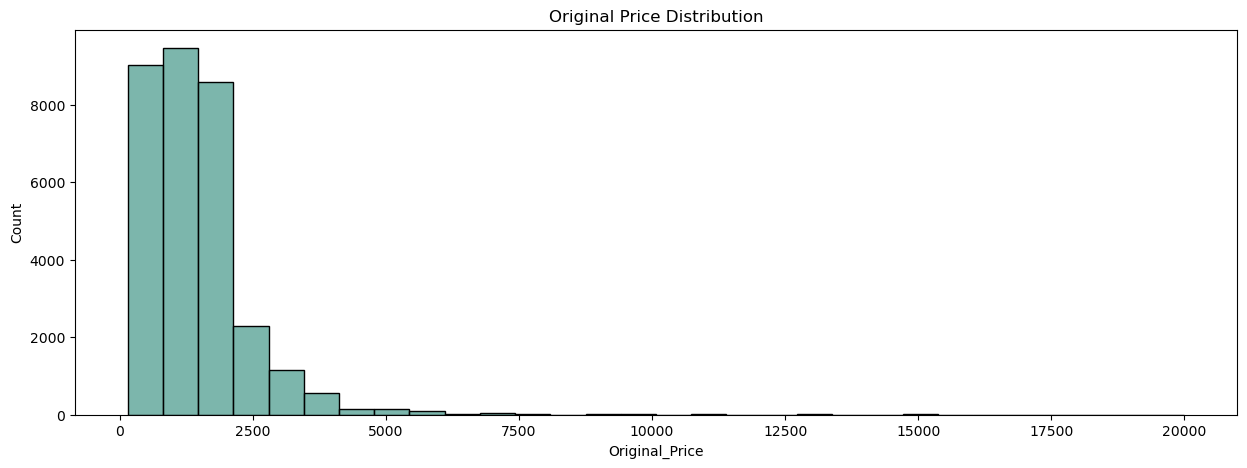

In [9]:
fig=plt.figure(figsize=(15,5))
sb.histplot(df.Original_Price,bins=30,color=color[1])
plt.title("Original Price Distribution")
plt.show()

### The distribution shows a strong concentration of products in the 1,000 to 2,000 price range, indicating a retail strategy focused on the mid-market segment.

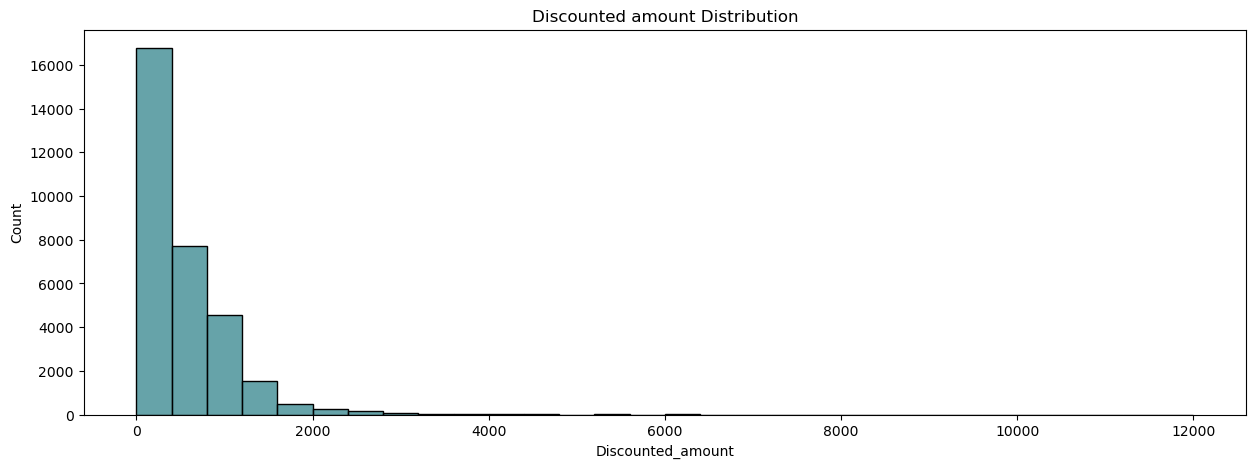

In [10]:
fig=plt.figure(figsize=(15,5))
sb.histplot(df.Discounted_amount,bins=30,color=color[2])
plt.title("Discounted amount Distribution")
plt.show()

### Most items get a very small discount (less than 500), showing the shop prefers tiny price cuts over big sales.

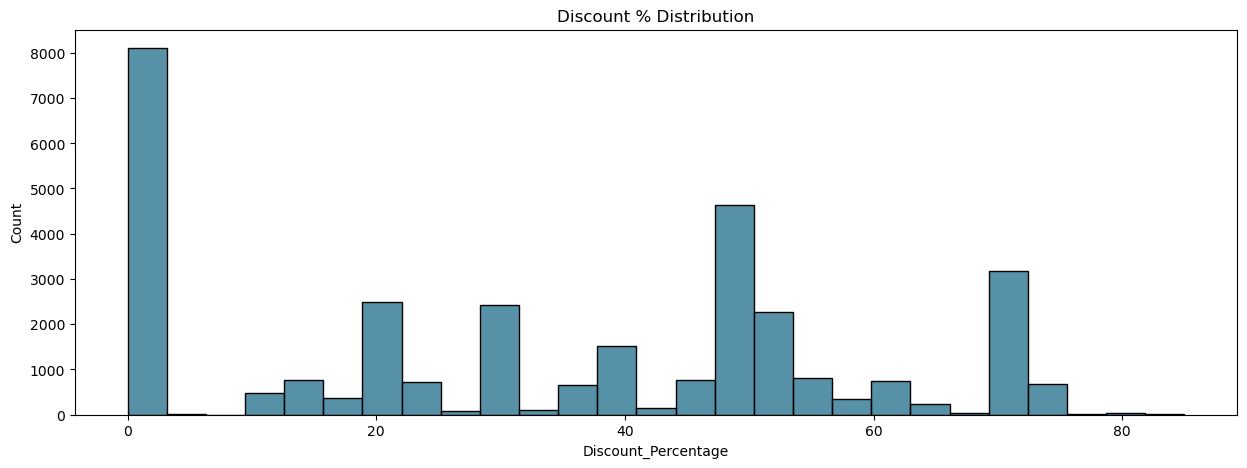

In [11]:
fig=plt.figure(figsize=(15,5))
sb.histplot(df.Discount_Percentage,color=color[3])
plt.title("Discount % Distribution")
plt.show()

### A lot of items have no discount at all, but for the ones that do, the shop loves using round numbers like 50% or 70% to catch people's eyes.

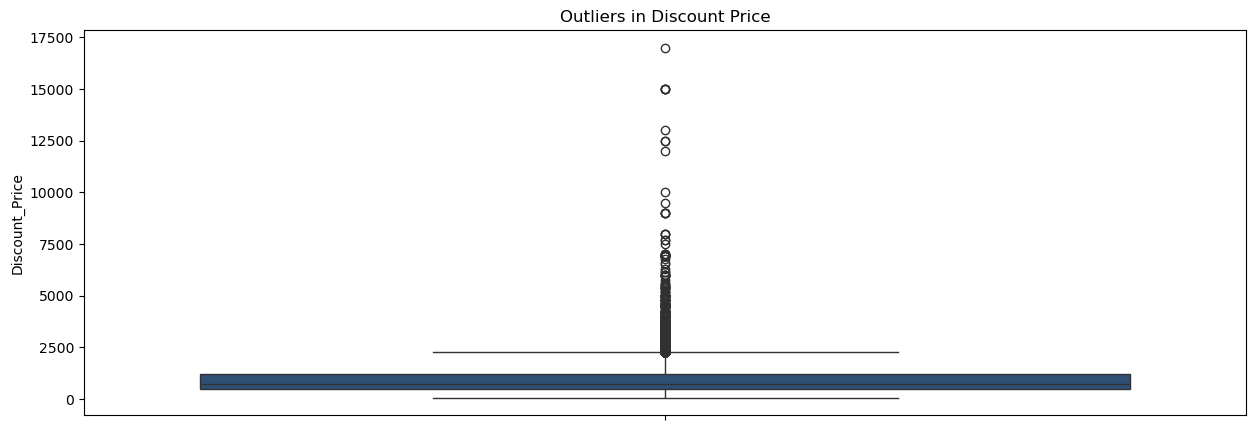

In [12]:
fig=plt.figure(figsize=(15,5))
sb.boxplot(df.Discount_Price,color=color[4])
plt.title("Outliers in Discount Price")
plt.show()

### The box is very flat at the bottom, meaning almost all clothes are cheap, but there are many "dots" at the top this shows that few very expensive luxury items.

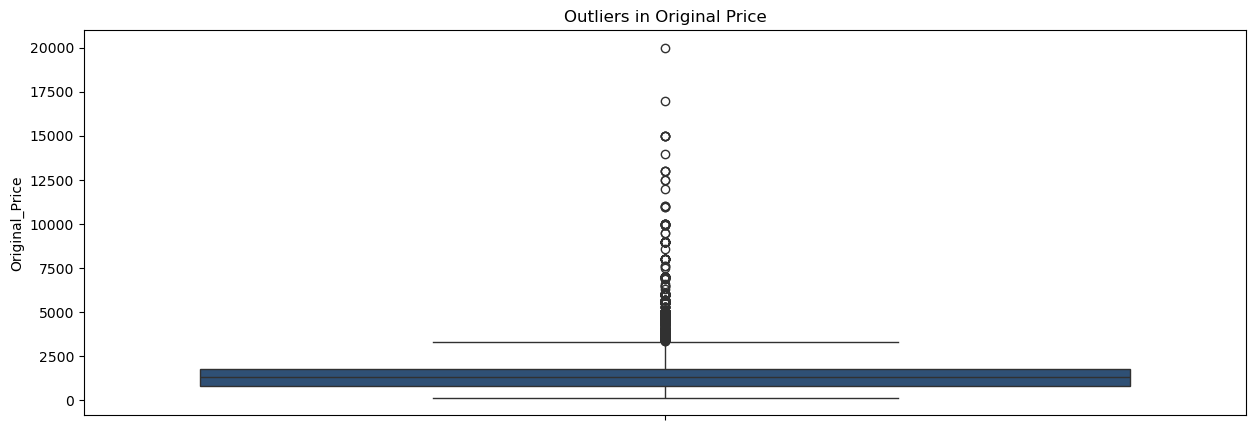

In [13]:
fig=plt.figure(figsize=(15,5))
sb.boxplot(df.Original_Price,color=color[4])
plt.title("Outliers in Original Price")
plt.show()

### The graph shows that nearly all items have a low starting price, but a few are costlier.

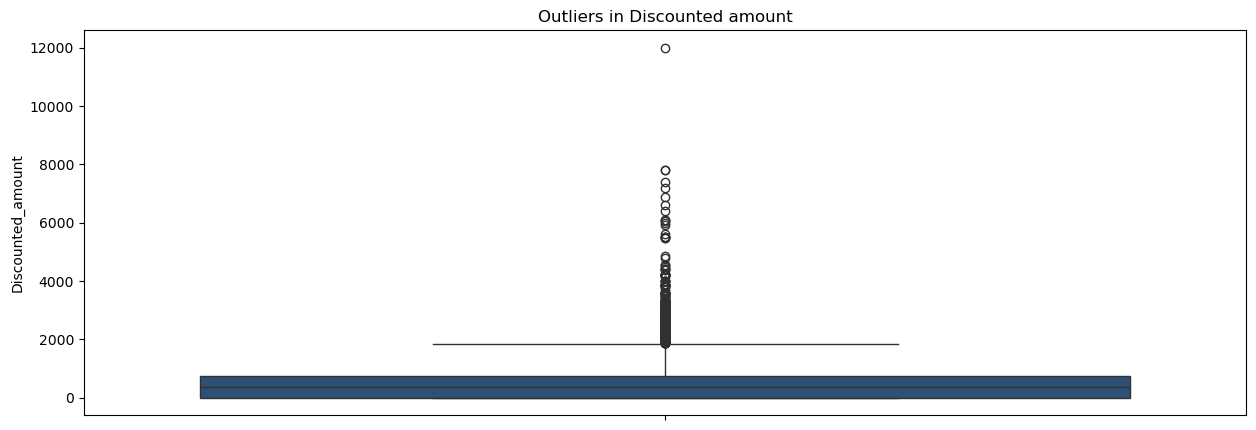

In [14]:
fig=plt.figure(figsize=(15,5))
sb.boxplot(df.Discounted_amount,color=color[4])
plt.title("Outliers in Discounted amount")
plt.show()

### Most clothes save you just a little bit of money, but a few rare items have huge price cuts.

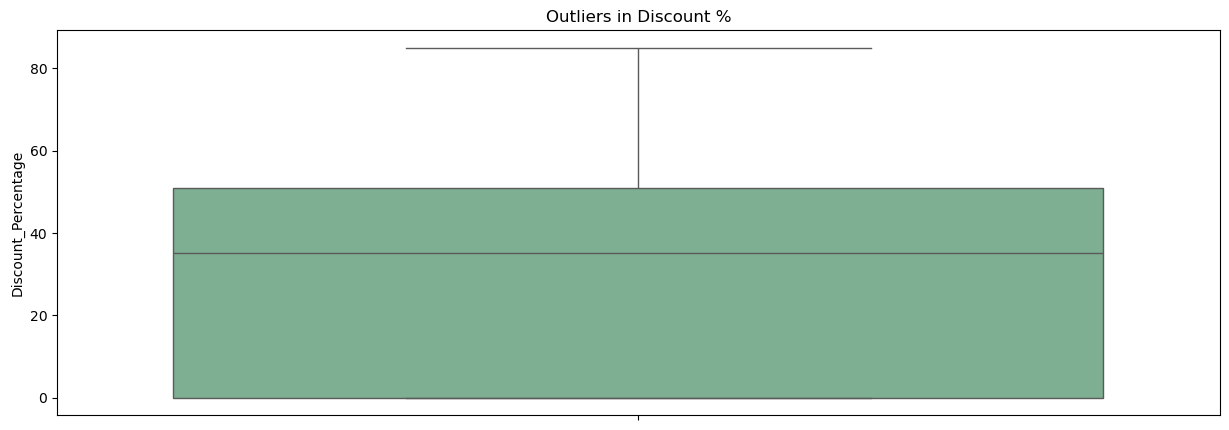

In [15]:
fig=plt.figure(figsize=(15,5))
sb.boxplot(df.Discount_Percentage,color=color[0])
plt.title("Outliers in Discount %")
plt.show()

### Most items have a discount between 0% and 50%, with the typical deal being around 35% off.

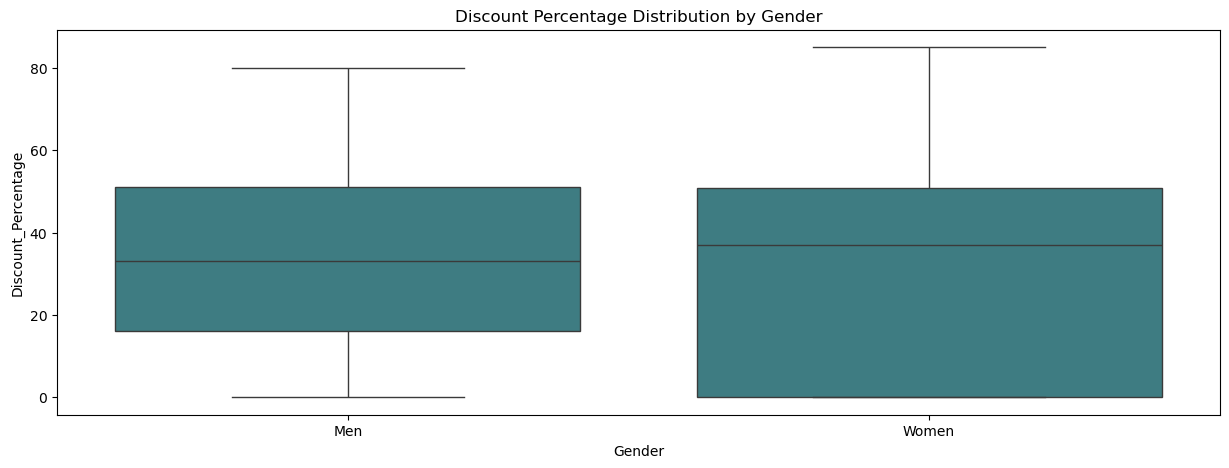

In [16]:
fig=plt.figure(figsize=(15,5))
sb.boxplot(x=df.Gender,y=df.Discount_Percentage,color=color[2])
plt.title("Discount Percentage Distribution by Gender")
plt.show()

### Women's clothes have a slightly higher typical discount and can reach much bigger price cuts than men's clothes.

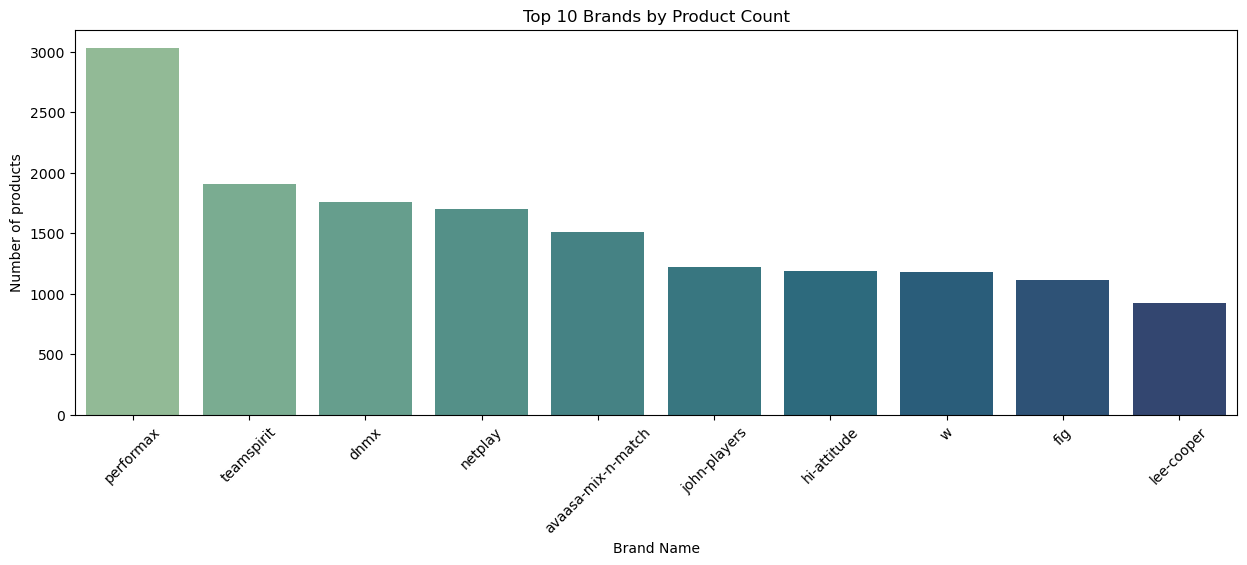

In [17]:
Brand_Count=df.Brand.value_counts().nlargest(10)
fig=plt.figure(figsize=(15,5))
sb.barplot(x=Brand_Count.index,y=Brand_Count.values,palette="crest")
plt.xlabel('Brand Name')
plt.ylabel('Number of products')
plt.title('Top 10 Brands by Product Count')
plt.xticks(rotation=45)
plt.show()

### Performax is the most popular brand by far, having way more clothes than any other brand on the list.

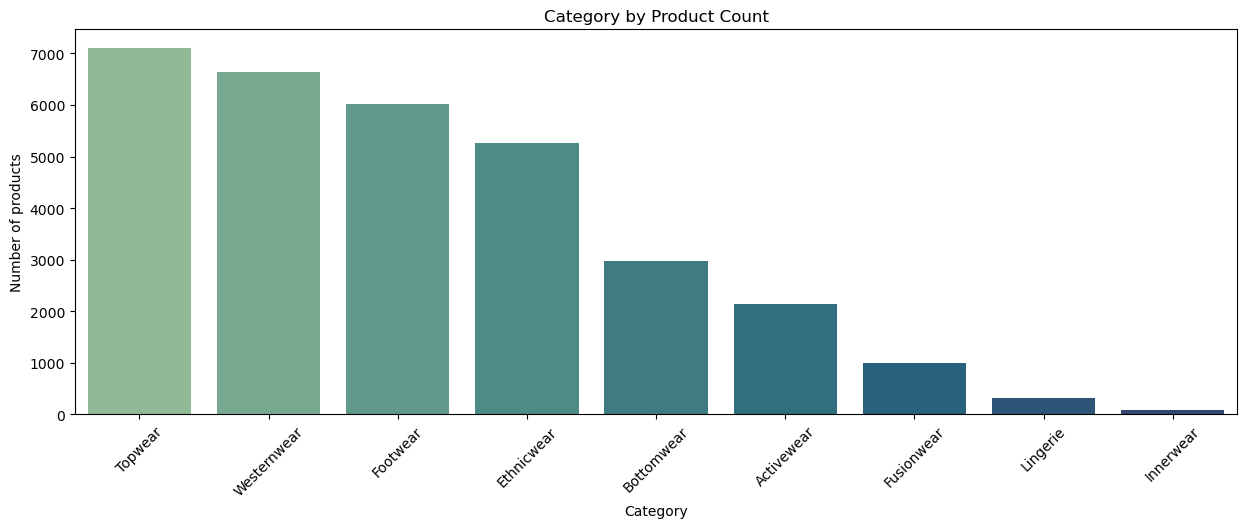

In [18]:
Category_Count=df.Category.value_counts()
fig=plt.figure(figsize=(15,5))
sb.barplot(x=Category_Count.index,y=Category_Count.values,palette="crest")
plt.xlabel('Category')
plt.ylabel('Number of products')
plt.title('Category by Product Count')
plt.xticks(rotation=45)
plt.show()

### Topwear is the most popular category with over 7,000 items, closely followed by Westernwear and Footwear.On the other hand, Lingerie and Innerwear have very few products, showing the shop focuses mostly on main outfits and shoes.

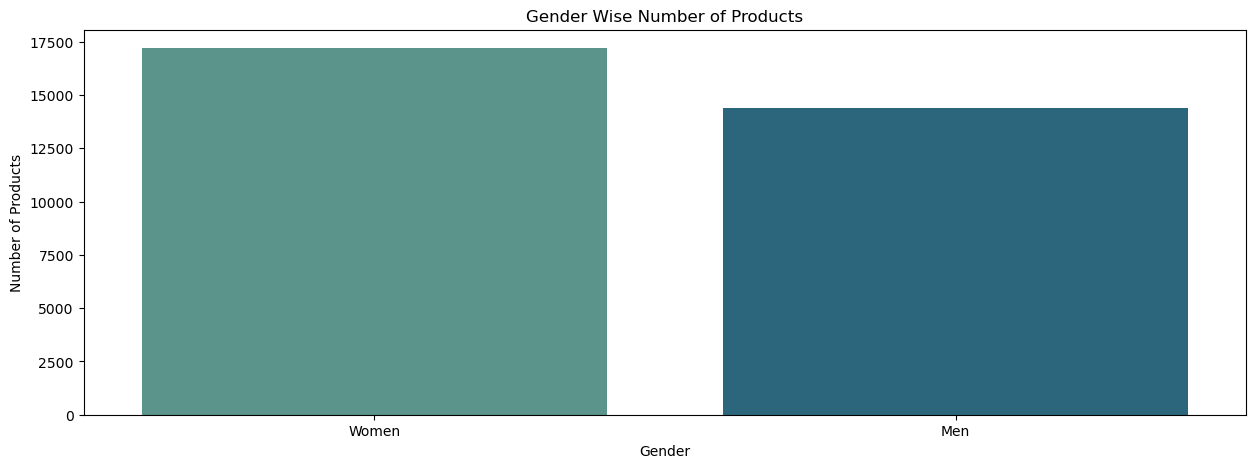

In [19]:
gender=df.Gender.value_counts()
fig=plt.figure(figsize=(15,5))
sb.barplot(x=gender.index,y=gender.values,palette="crest")
plt.xlabel('Gender')
plt.ylabel('Number of Products')
plt.title('Gender Wise Number of Products')
plt.xticks(rotation=0)
plt.show()

### There are more products for women than for men in this shop.The store seems to focus a bit more on female shoppers.

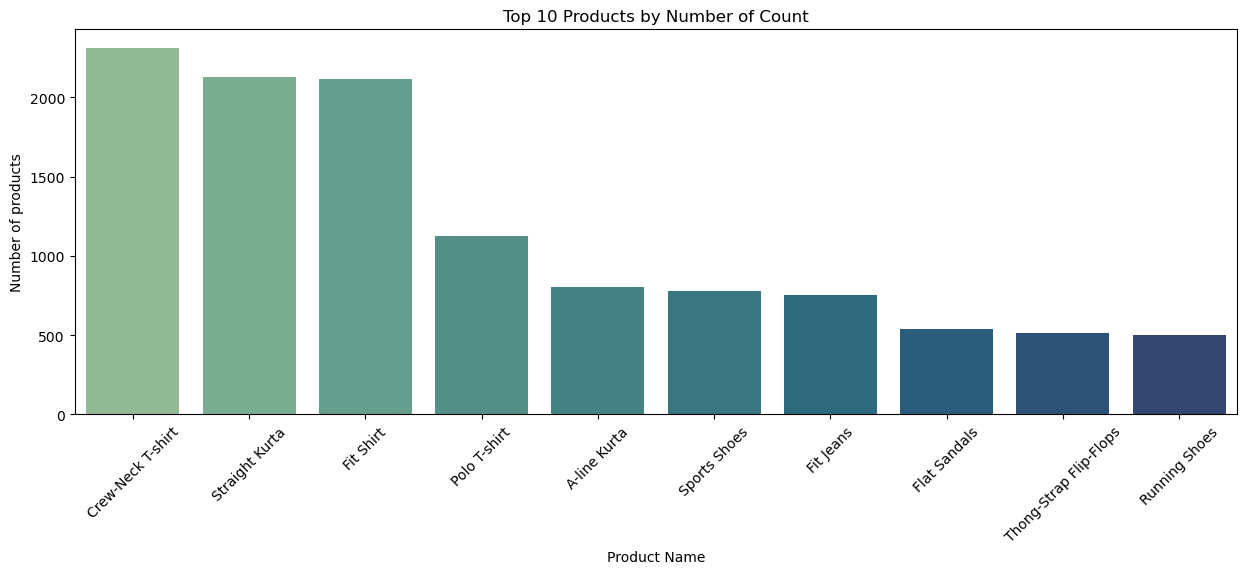

In [20]:
Product_Count=df.Product_Name.value_counts().nlargest(10)
fig=plt.figure(figsize=(15,5))
sb.barplot(x=Product_Count.index,y=Product_Count.values,palette="crest")
plt.xlabel('Product Name')
plt.ylabel('Number of products')
plt.title('Top 10 Products by Number of Count')
plt.xticks(rotation=45)
plt.show()

### T-shirts, kurtas, and shirts are the most common items, with over 2,000 of each available.

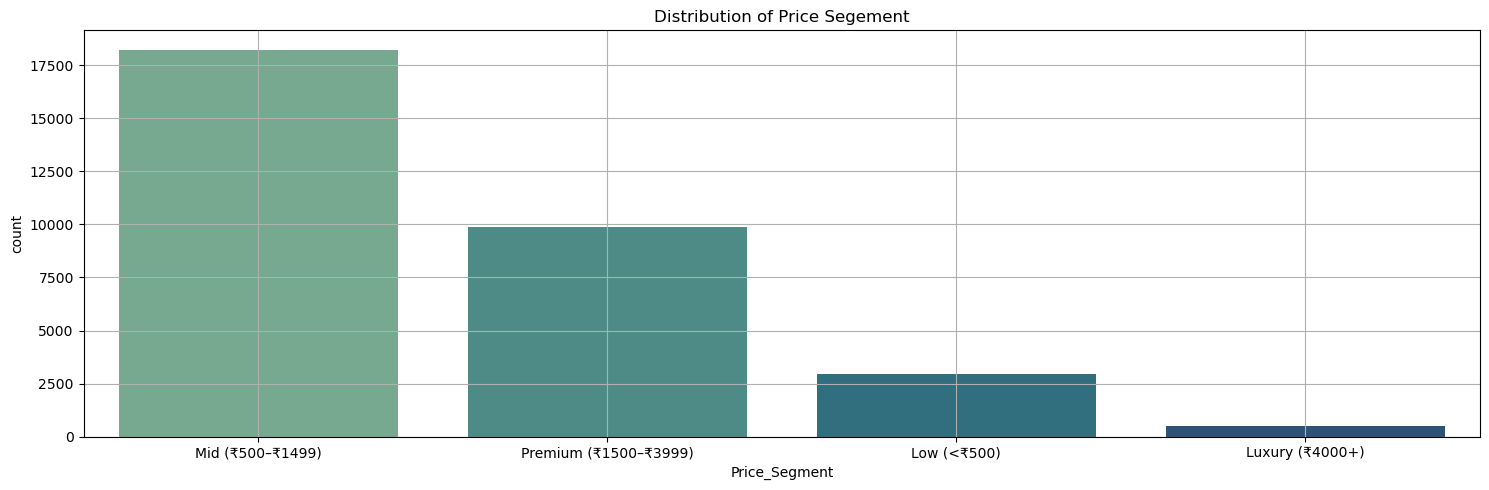

In [37]:
fig=plt.figure(figsize=(15,5))
sb.countplot(x=df.Price_Segment,palette="crest")
plt.grid(True)
plt.title("Distribution of Price Segement")
plt.tight_layout()

### Most clothes are mid-priced (500–1,499) for regular shoppers, while expensive luxury items are very rare. This shows the store focuses on being affordable rather than selling high-end fashion.

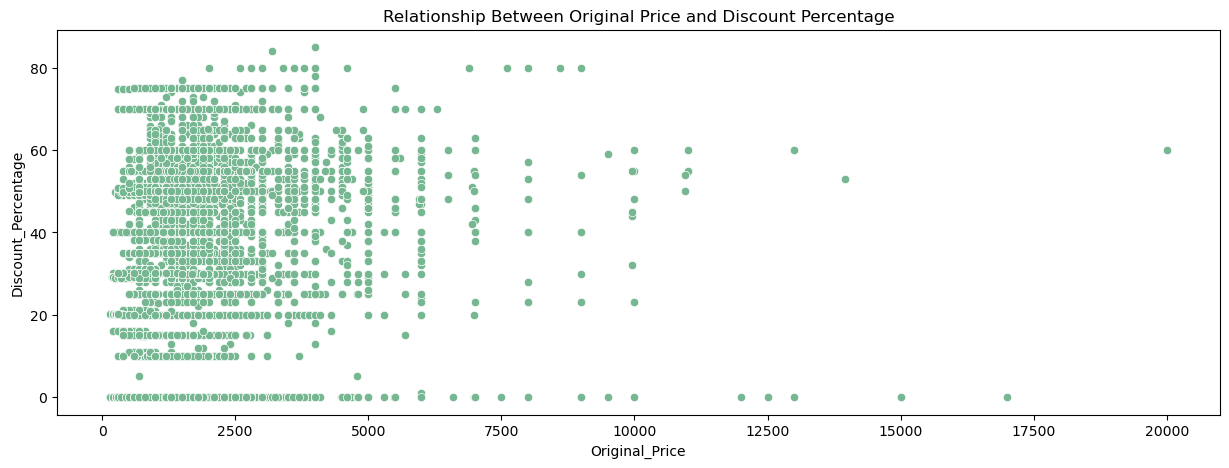

In [22]:
fig=plt.figure(figsize=(15,5))
sb.scatterplot(x=df.Original_Price,y=df.Discount_Percentage,color=color[0])
plt.title("Relationship Between Original Price and Discount Percentage")
plt.show()

### Big discounts happen mostly on cheaper clothes, while the very expensive items usually have zero or much smaller price cuts.

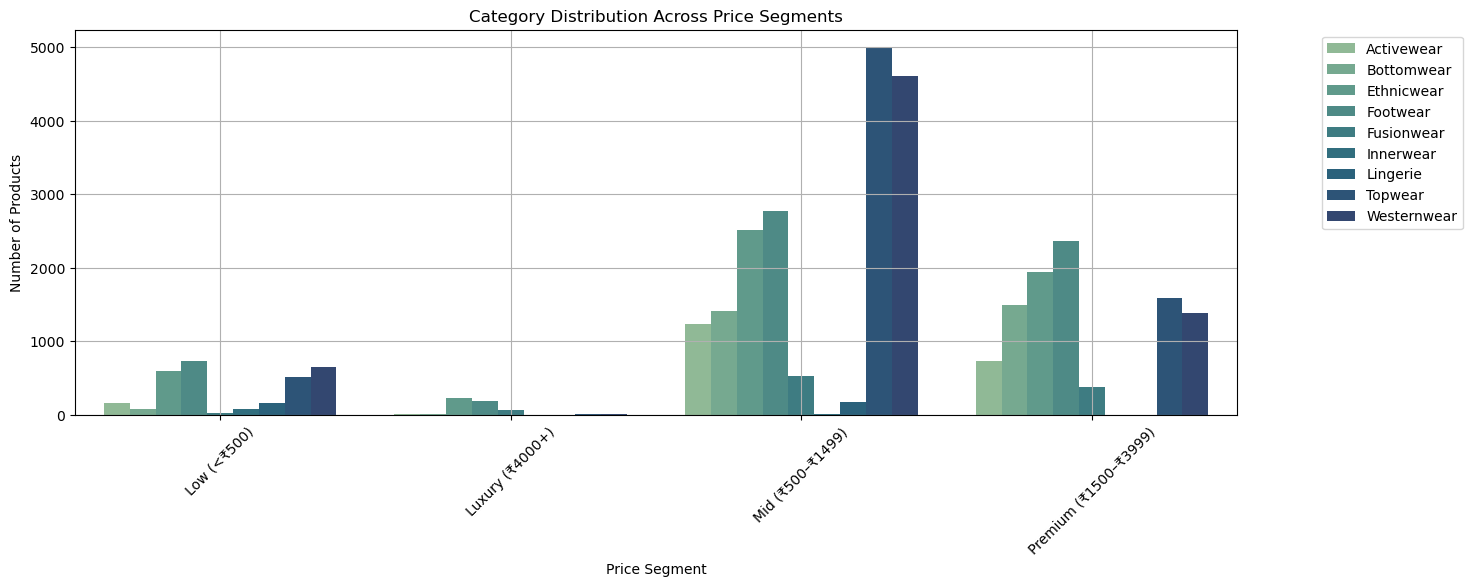

In [23]:
category_by_price = df.groupby(['Price_Segment', 'Category']).size().reset_index(name='Count')
plt.figure(figsize=(15,5))
sb.barplot(x=category_by_price.Price_Segment, y=category_by_price.Count, hue=category_by_price.Category,palette="crest" )
plt.legend(bbox_to_anchor=(1.2,1.0))
plt.xticks(rotation=45)
plt.xlabel('Price Segment')
plt.ylabel('Number of Products')
plt.title('Category Distribution Across Price Segments')
plt.grid(True)
plt.show()

### In Low price segment Footwear and Westernwear dominate, In Mid price segment Topwear and Footwear dominate,In Premium Price segment Footwear and Ethnicwear dominate and In Luxury Price Segment Ethnicwear and Footwear dominate.

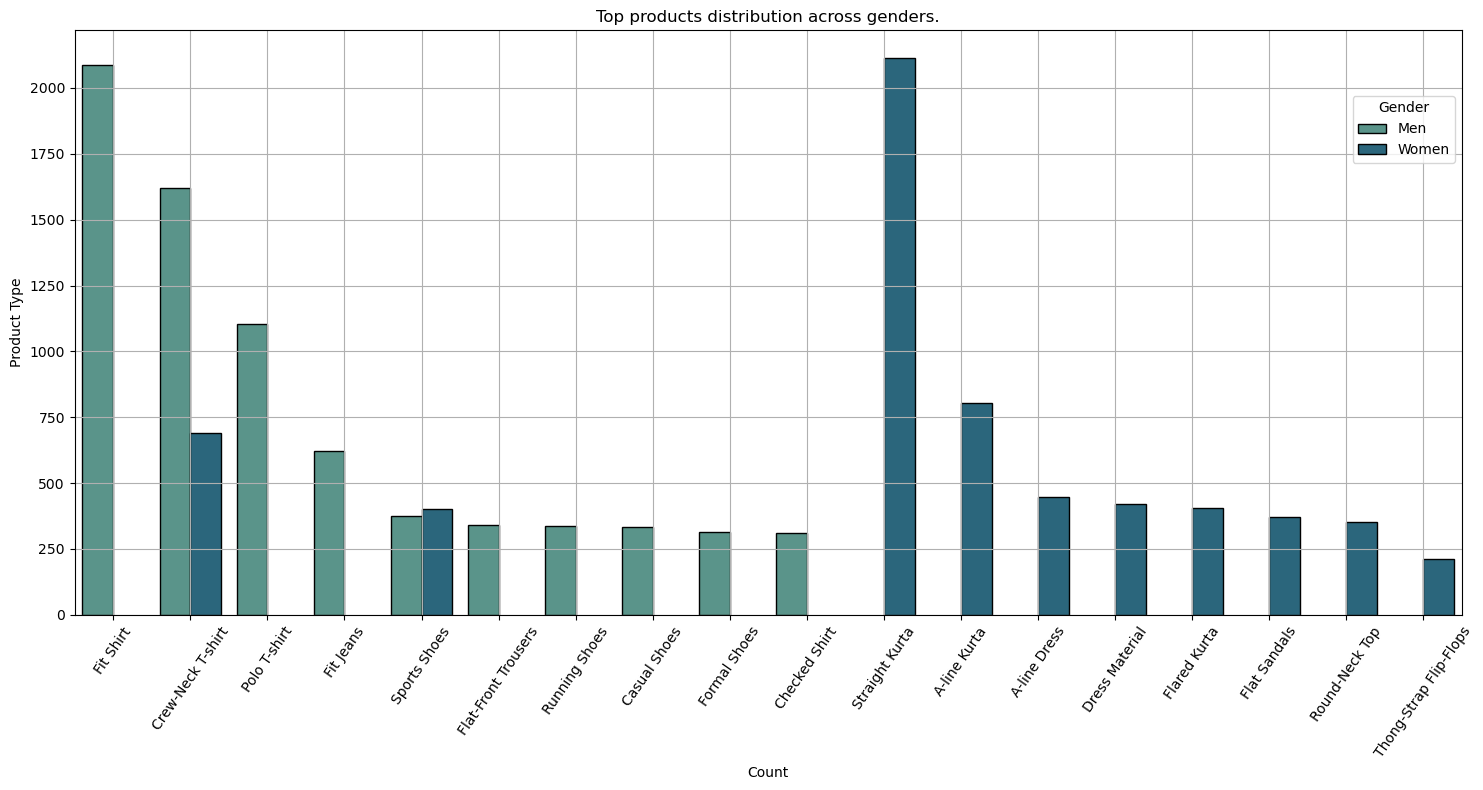

In [24]:
top_products_across_gender = df.groupby(['Gender','Product_Name']).size().reset_index(name='Count').sort_values(['Gender','Count'],ascending=[True,False])
top_products_across_gender = top_products_across_gender.groupby('Gender').head(10)

plt.figure(figsize=(15,8))
sb.barplot(y=top_products_across_gender.Count, x=top_products_across_gender.Product_Name,
             hue=top_products_across_gender.Gender, dodge=True, palette="crest",edgecolor='black')

plt.title("Top products distribution across genders.")
plt.xlabel("Count")
plt.ylabel("Product Type")
plt.xticks(rotation=55)
plt.legend(title="Gender",bbox_to_anchor=(1.0,0.9))
plt.tight_layout()
plt.grid(True)
plt.show()

### Men mostly buy Fit Shirts and T-shirts, while women go for Straight Kurtas by a huge margin. It shows the shop has very clear "favorites" for each gender, with casual tops being the top choice for everyone.

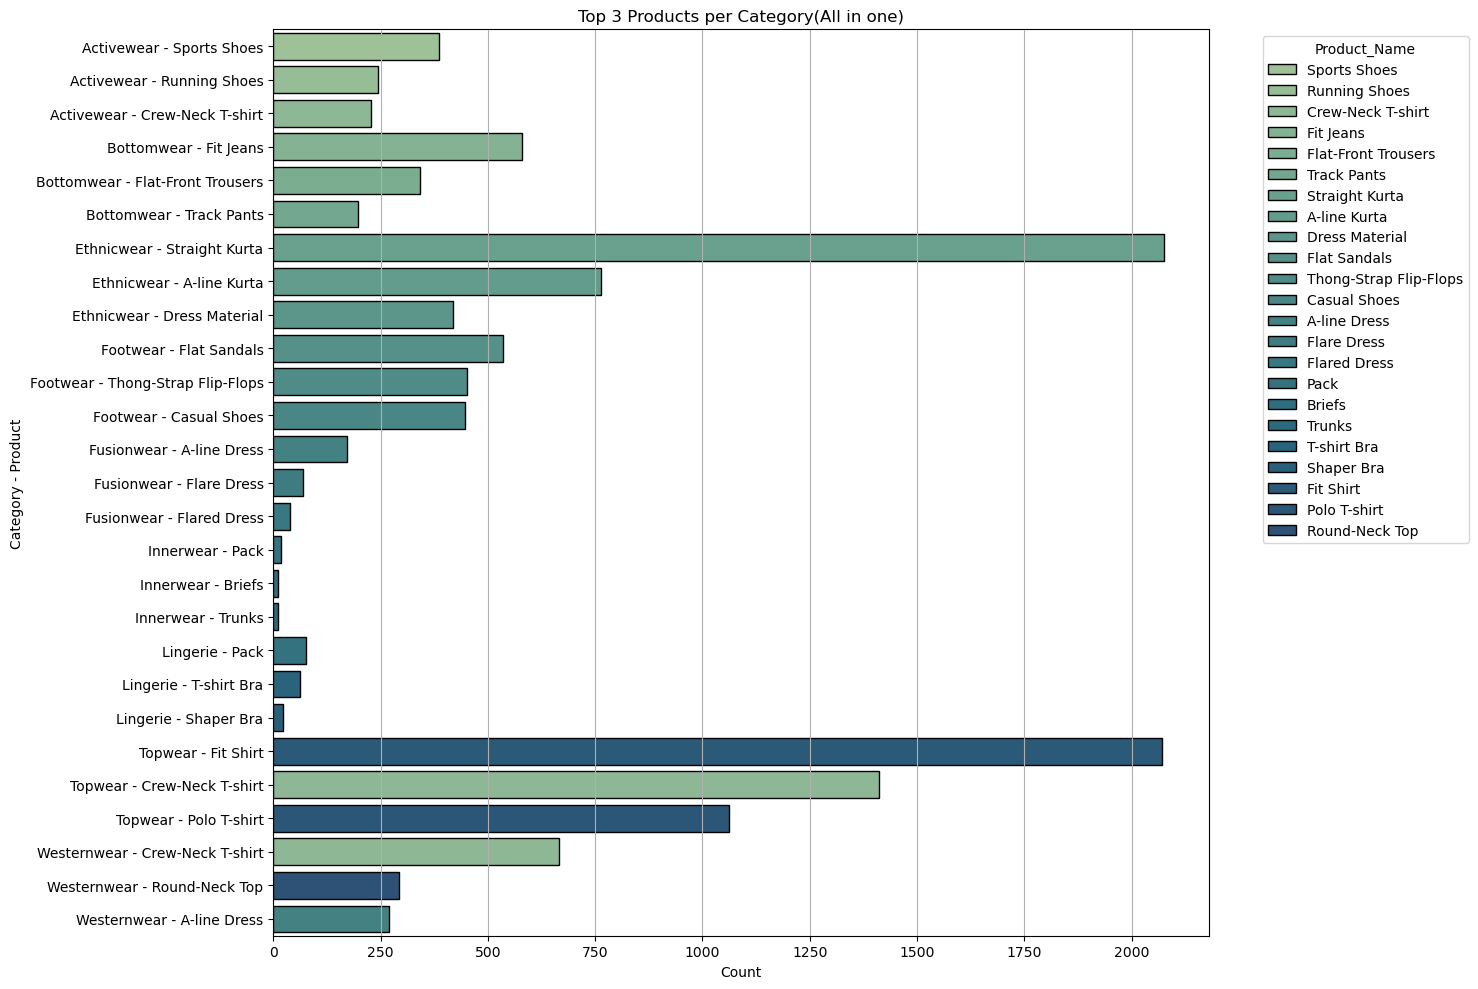

In [25]:
counts = df.groupby(['Category', 'Product_Name']).size().reset_index(name='Count')
top_products = (counts.sort_values(['Category', 'Count'], ascending=[True, False]).groupby('Category').head(3))
top_products['Label'] = (top_products['Category'] + " - " + top_products['Product_Name'])
plt.figure(figsize=(15, 10))
sb.barplot(x=top_products.Count,y=top_products.Label,hue=top_products.Product_Name,palette=sb.color_palette("crest", len(top_products)),edgecolor='black')
plt.title('Top 3 Products per Category(All in one)')
plt.xlabel('Count')
plt.ylabel('Category - Product')
plt.legend(title='Product_Name',bbox_to_anchor=(1.05,1),loc='upper left')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

## In Activewear Crew-Neck T-Shirt is highest selling,In Bottomewear Fit Jeans is highest selling,In Ethnicewear Straight Kurta is highest selling,In Footewear Flat Sandals is highest selling,In Fusionwear A-line Dress is highest selling,In Innearewear Pack is highest selling,In Lingerie Pack is highest selling,In Topwear Fit-Shirt is highest selling,In Westernwear Crew-Neck-T-Shirt is highest selling.

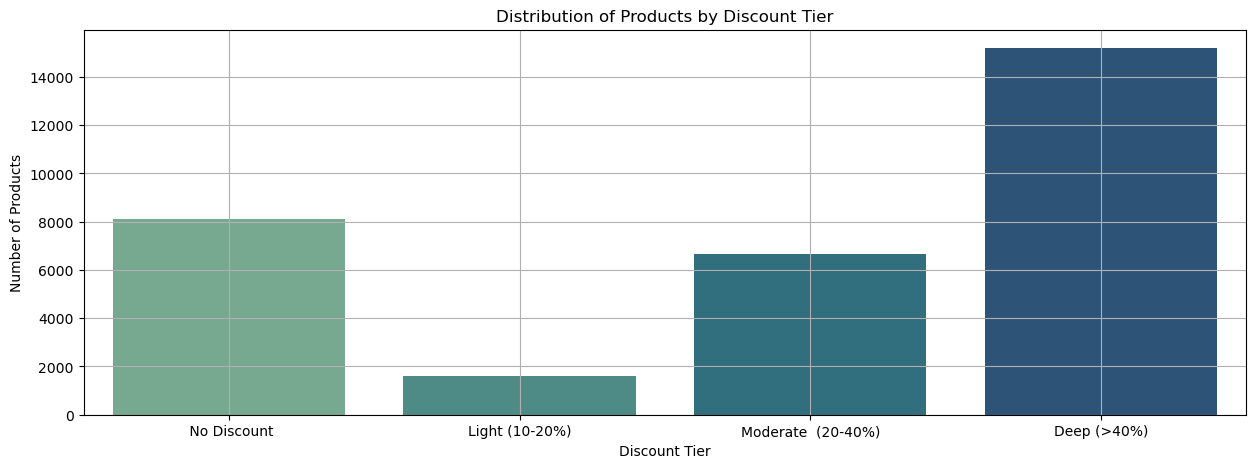

In [26]:
discount_tier_count = df.groupby('Discount_Tier').size().reset_index(name='Count')
order = [' No Discount','Light (10-20%)','Moderate  (20-40%)','Deep (>40%)']
plt.figure(figsize=(15,5))
sb.barplot(x=discount_tier_count.Discount_Tier,y=discount_tier_count.Count,order=order,palette="crest")
plt.xlabel('Discount Tier')
plt.ylabel('Number of Products')
plt.title('Distribution of Products by Discount Tier')
plt.grid(True)
plt.show()

### The shop uses a very aggressive sales plan, with Deep Discounts (over 40%) being the most common by far.

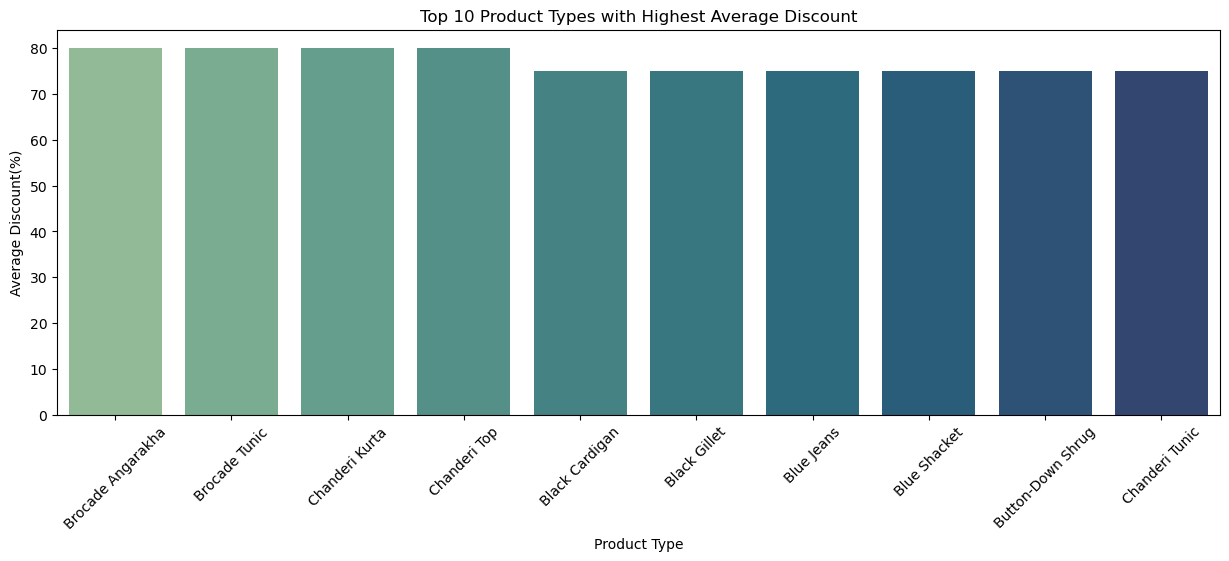

In [27]:
avg_discount_product = df.groupby('Product_Name')['Discount_Percentage'].mean()
top_discount_products=(avg_discount_product.nlargest(10))
plt.figure(figsize=(15,5))
sb.barplot(x=top_discount_products.index, y=top_discount_products.values,palette="crest")
plt.xticks(rotation=45)
plt.xlabel('Product Type')
plt.ylabel('Average Discount(%)')
plt.title('Top 10 Product Types with Highest Average Discount')
plt.show()

### Traditional ethnic items like Brocade and Chanderi outfits get the highest price cuts, reaching a huge 80% off.

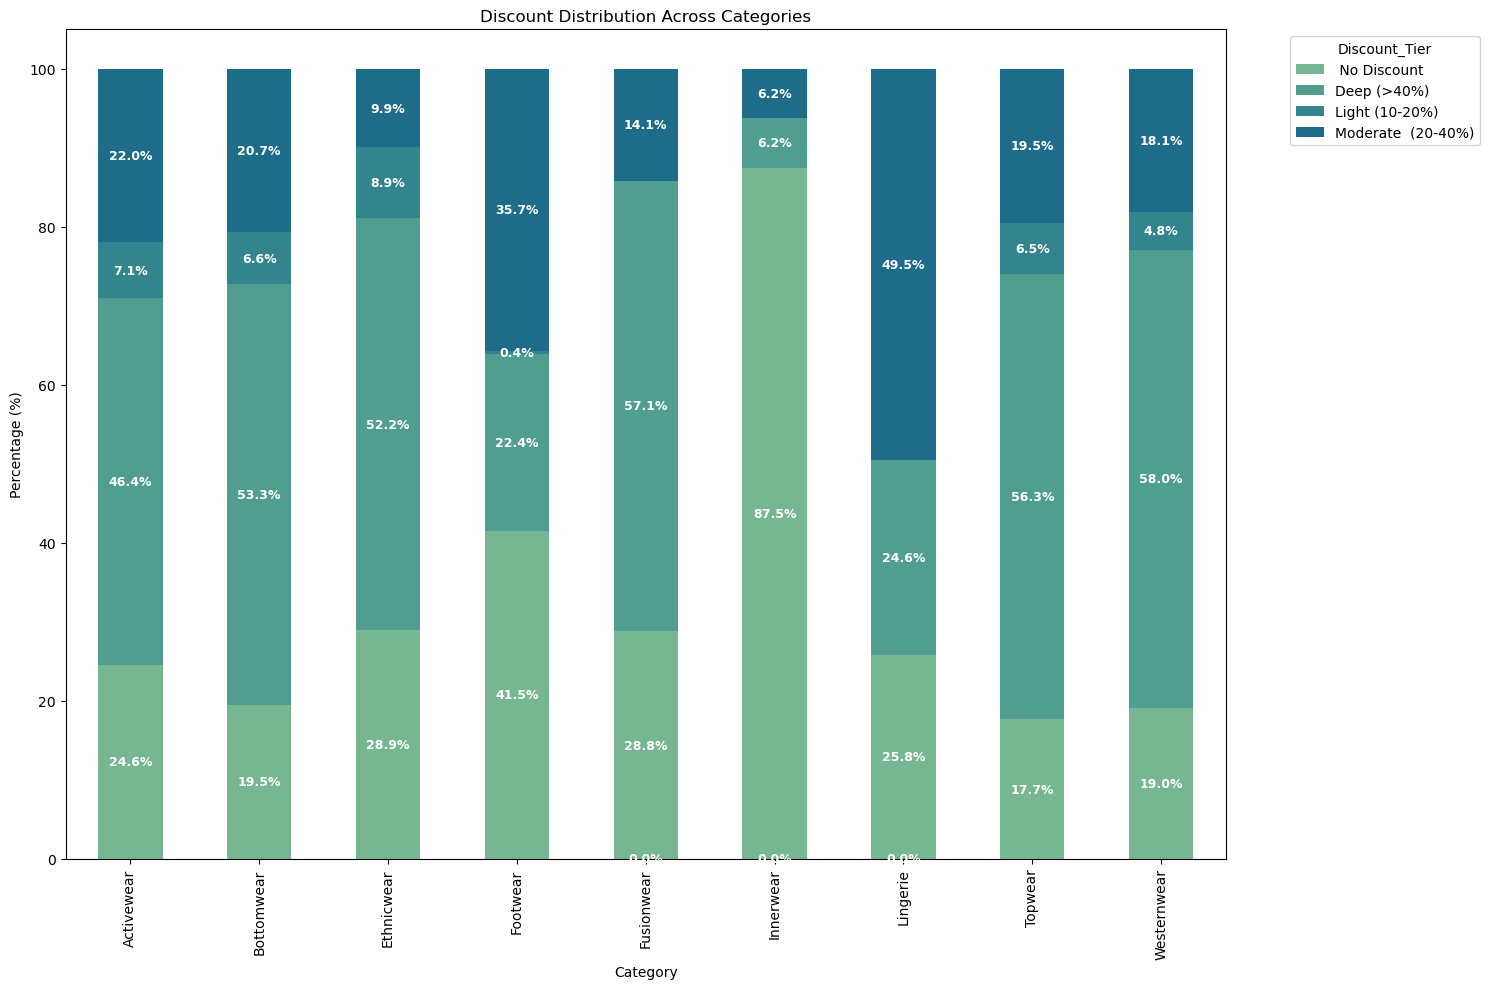

In [28]:
pivot_df=pd.pivot_table(df,index='Category',columns='Discount_Tier',aggfunc='size',fill_value=0)
row_total = pivot_df.sum(axis=1)
pivot_pct = pivot_df.div(row_total, axis=0)*100
ax = pivot_pct.plot(kind='bar', stacked=True, figsize=(15,10),color=color)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=9, color='white', fontweight='bold')
plt.title('Discount Distribution Across Categories')
plt.xlabel('Category')
plt.ylabel('Percentage (%)')
plt.legend(title='Discount_Tier', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Fusionwear and Westernwear have the most big sales (over 50%), while almost all Innerwear is sold at full price. It shows that the store gives huge discounts on main clothes but keeps basic items more expensive.

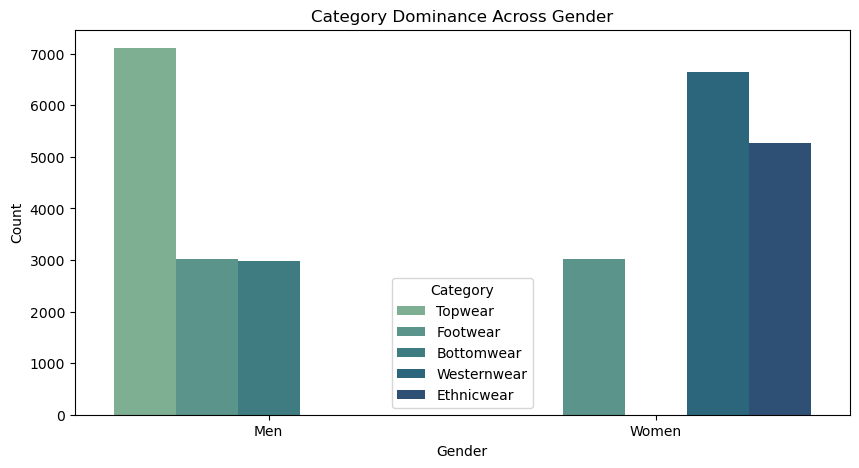

In [29]:
category_dominance_Gender = df.groupby(['Gender', 'Category']).size().reset_index(name='Count').sort_values(['Gender', 'Count'], ascending=[True, False])
top_category_dominance_Gender = category_dominance_Gender.groupby('Gender').head(3)
fig=plt.figure(figsize=(10,5))
sb.barplot(x=top_category_dominance_Gender.Gender,y=top_category_dominance_Gender.Count,hue=top_category_dominance_Gender.Category,palette="crest")
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Category Dominance Across Gender')
plt.show()

### IN Mens Wear  Topwear is dominating category and   IN Womens Wear  Westernwear is dominating category.

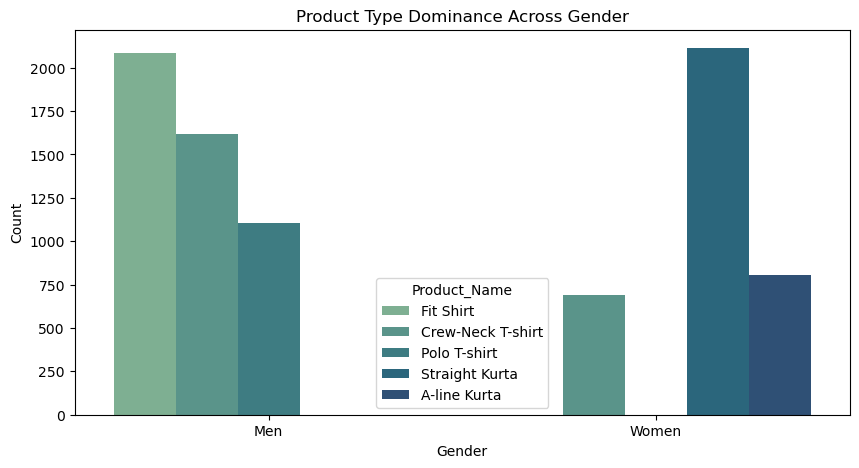

In [30]:
prod_dominance_Gender = df.groupby(['Gender', 'Product_Name']).size().reset_index(name='Count').sort_values(['Gender', 'Count'], ascending=[True, False])
top_prod_dominance_Gender= prod_dominance_Gender.groupby('Gender').head(3)
fig=plt.figure(figsize=(10,5))
sb.barplot(x=top_prod_dominance_Gender.Gender,y=top_prod_dominance_Gender.Count,hue=top_prod_dominance_Gender.Product_Name,palette="crest")
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Product Type Dominance Across Gender')
plt.show()

### In Mens Fit-Shirt is dominating Product Type and In Womens Wear Straigh Kurta is dominating Product Type.

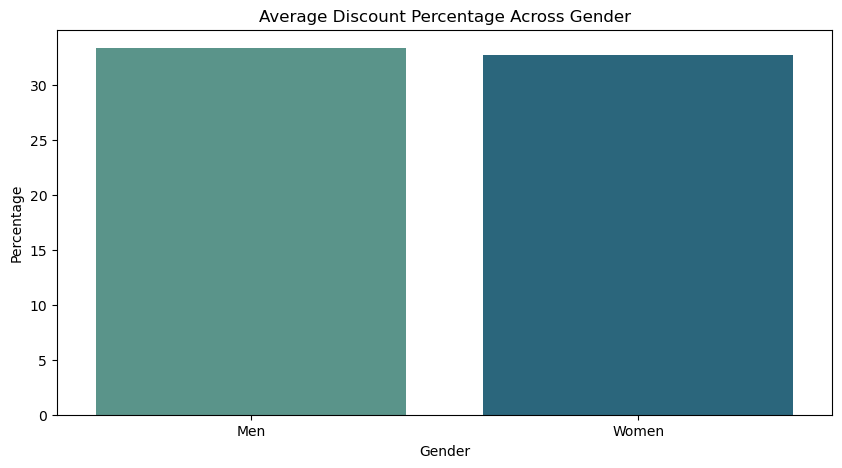

In [31]:
avg_discount = df.groupby('Gender')['Discount_Percentage'].mean().reset_index()
fig=plt.figure(figsize=(10,5))
sb.barplot(x=avg_discount.Gender,y=avg_discount.Discount_Percentage,palette="crest")
plt.xlabel('Gender')
plt.ylabel('Percentage')
plt.title('Average Discount Percentage Across Gender')
plt.show()

### The Average Discount in Mens Wear is greater than Womens wear.

Text(0.5, 1.0, 'Price Segment Dominance Across Multiple Categories')

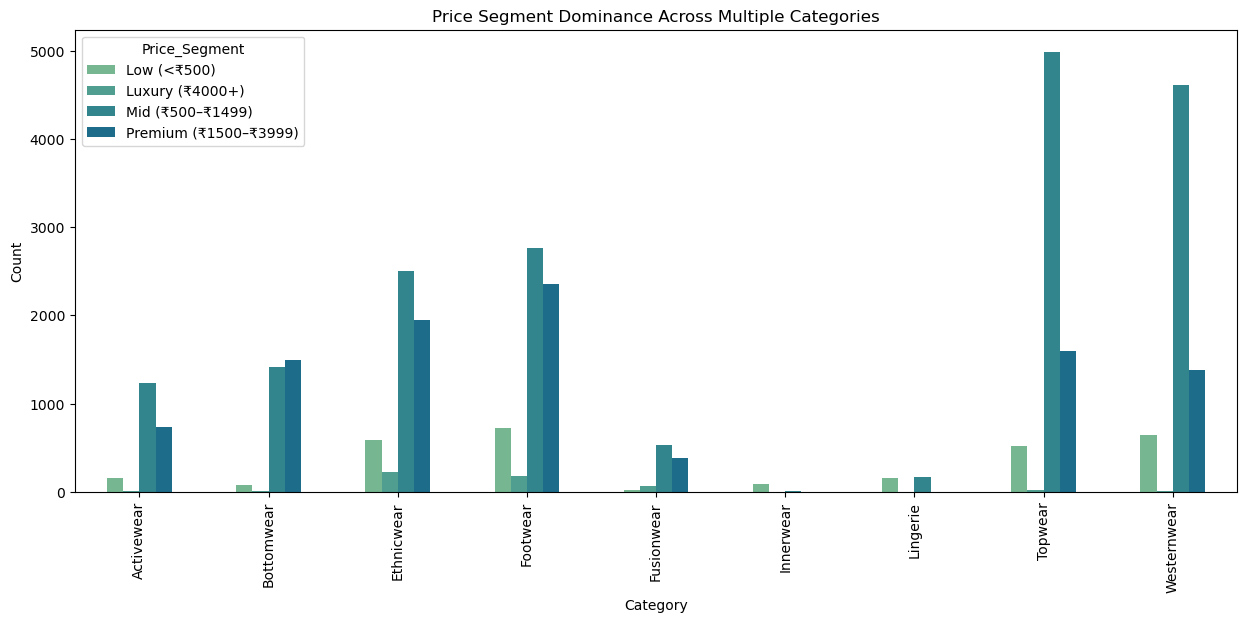

In [32]:
category_dominate=pd.crosstab(index=df.Category,columns=df.Price_Segment,)
category_dominate.plot(kind='bar',figsize=(15,6),color=color)
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Price Segment Dominance Across Multiple Categories')

#### In ActiveWear Premium segment is dominating, In BottomWear Premium segment is dominating, In EthnicWear Mid segment is dominating, In Fusionwear	Mid segment is dominating, In Footwear Mid segment is dominating , In Innerwear	Low segment is dominating, In Lingerie Mid segment is dominating, In Topwear	Mid segment is dominating, In Westernwear Mid segment is dominating.

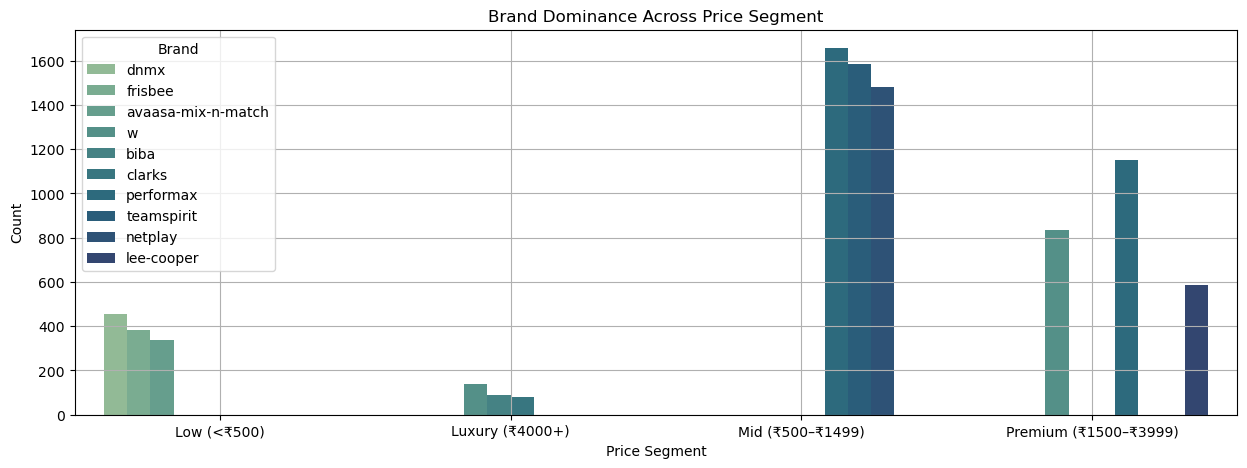

In [33]:
Brand_dominance_by_PriceSegmnet = df.groupby(['Brand', 'Price_Segment']).size().reset_index(name='Count').sort_values(['Price_Segment', 'Count'], ascending=[True, False])
top_Brand_dominance_by_PriceSegmnet= Brand_dominance_by_PriceSegmnet.groupby('Price_Segment').head(3)
fig=plt.figure(figsize=(15,5))
sb.barplot(x=top_Brand_dominance_by_PriceSegmnet.Price_Segment,y=top_Brand_dominance_by_PriceSegmnet.Count,hue=top_Brand_dominance_by_PriceSegmnet.Brand,palette="crest")
plt.xlabel('Price Segment')
plt.ylabel('Count')
plt.title('Brand Dominance Across Price Segment')
plt.grid(True)
plt.show()

### In Low Price Segment DNMX Brand is at Top, In Mid Price Segment Perforamax Brand is at Top, In  Premium Segment Perforamax Brand is at Top, In Luxury Price Segment W Brand is at Top.

In [52]:
top_Brand_dominance_by_PriceSegmnet

,Brand,Price_Segment,Count
99,dnmx,Low (<₹500),453
133,frisbee,Low (<₹500),385
37,avaasa-mix-n-match,Low (<₹500),339
342,w,Luxury (₹4000+),139
51,biba,Luxury (₹4000+),91
73,clarks,Luxury (₹4000+),82
262,performax,Mid (₹500–₹1499),1657
320,teamspirit,Mid (₹500–₹1499),1583
229,netplay,Mid (₹500–₹1499),1479
263,performax,Premium (₹1500–₹3999),1153
